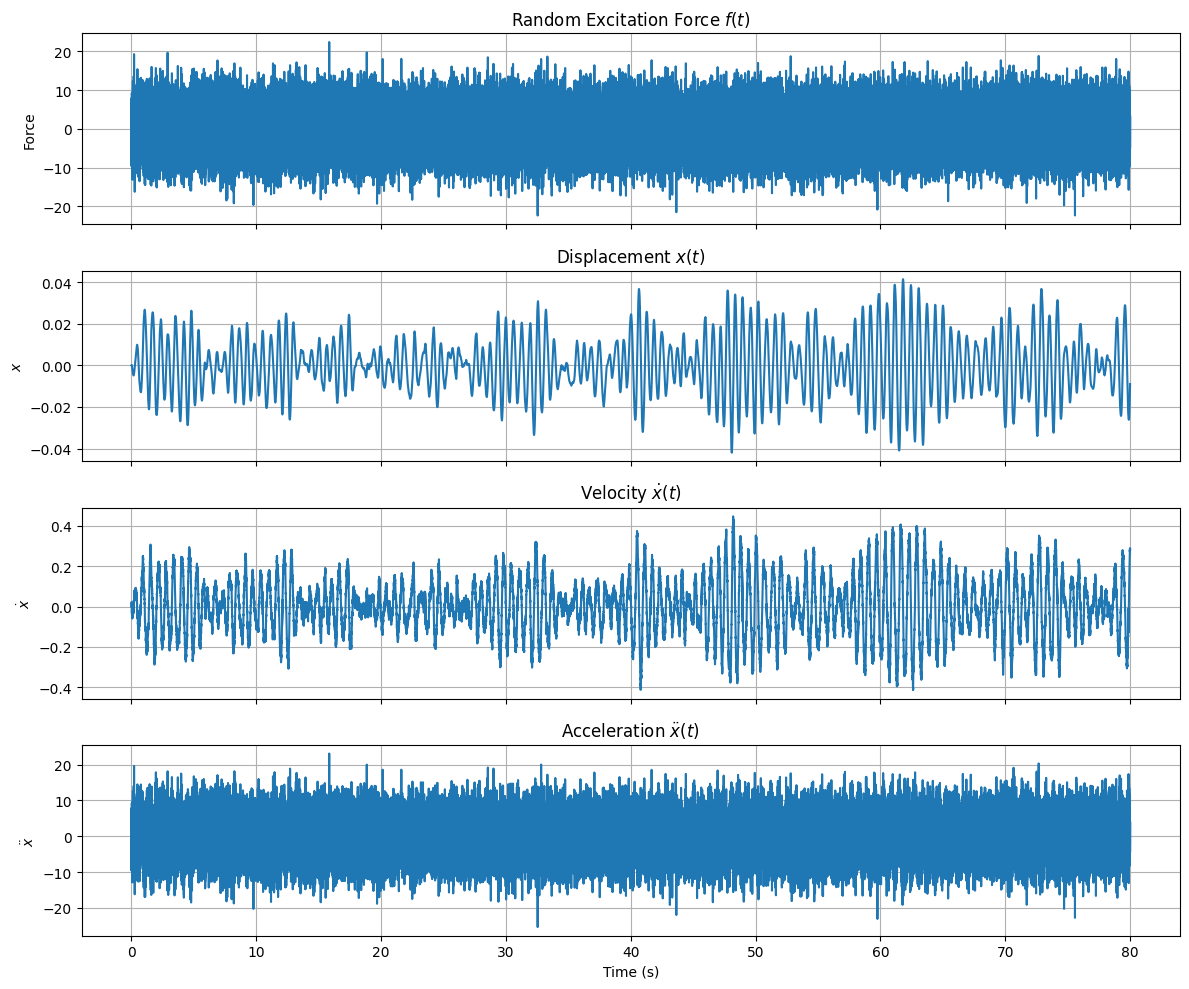

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Parameters
# --------------------------------------------------
m = 1.0          # mass
c = 0.8          # damping
k = 100.0         # stiffness

dt = 0.001       # time step
t_end = 80.0     # total simulation time
n = int(t_end / dt)

# Initial conditions
x0 = 0.0
v0 = 0.0

# Random force settings
force_std = 5.0          # standard deviation of random force
random_seed = 42         # for reproducibility

# --------------------------------------------------
# Time array
# --------------------------------------------------
t = np.linspace(0, t_end, n + 1)

# --------------------------------------------------
# Generate random excitation force
# --------------------------------------------------
np.random.seed(random_seed)
f = force_std * np.random.randn(n + 1)   # zero-mean white-noise-like force

# --------------------------------------------------
# Arrays
# --------------------------------------------------
x = np.zeros(n + 1)
v = np.zeros(n + 1)
a = np.zeros(n + 1)

x[0] = x0
v[0] = v0
a[0] = (f[0] - c * v[0] - k * x[0]) / m

# --------------------------------------------------
# Euler method
# --------------------------------------------------
for i in range(n):
    # acceleration at current step
    a[i] = (f[i] - c * v[i] - k * x[i]) / m

    # Euler update
    x[i + 1] = x[i] + dt * v[i]
    v[i + 1] = v[i] + dt * a[i]

# final acceleration
a[n] = (f[n] - c * v[n] - k * x[n]) / m

# --------------------------------------------------
# Plot results
# --------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(t, f)
axes[0].set_title('Random Excitation Force $f(t)$')
axes[0].set_ylabel('Force')
axes[0].grid(True)

axes[1].plot(t, x)
axes[1].set_title('Displacement $x(t)$')
axes[1].set_ylabel('$x$')
axes[1].grid(True)

axes[2].plot(t, v)
axes[2].set_title('Velocity $\dot{x}(t)$')
axes[2].set_ylabel(r'$\dot{x}$')
axes[2].grid(True)

axes[3].plot(t, a)
axes[3].set_title('Acceleration $\ddot{x}(t)$')
axes[3].set_xlabel('Time (s)')
axes[3].set_ylabel(r'$\ddot{x}$')
axes[3].grid(True)

plt.tight_layout()
plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def random_decrement(signal, dt, m, k, trigger_ratio=1.4, trigger_mode="any", n_cycles=5, min_gap=None):
    """
    Compute Random Decrement signature for any 1D signal.

    Parameters
    ----------
    signal : array_like
        Input signal (e.g. displacement x, velocity v, or acceleration a)
    dt : float
        Sampling time step
    m, k : float
        Mass and stiffness, used to estimate natural period
    trigger_ratio : float
        Trigger level = trigger_ratio * std(signal)
    trigger_mode : str
        'up'   -> upward crossings only
        'down' -> downward crossings only
        'any'  -> both upward and downward crossings
    n_cycles : float
        Segment length in number of natural periods
    min_gap : int or None
        Minimum number of samples between accepted triggers.
        If None, defaults to segment_length

    Returns
    -------
    tau : ndarray
        Local time axis of RD segment
    rd_signature : ndarray
        Averaged Random Decrement signature
    segments : ndarray
        Array of all extracted segments
    trigger_indices : ndarray
        Accepted trigger indices
    trigger_level : float
        Trigger threshold used
    segment_length : int
        Number of samples in each segment
    """
    signal = np.asarray(signal)

    # Trigger level
    trigger_level = trigger_ratio * np.std(signal)

    # Natural period
    omega_n = np.sqrt(k / m)
    Tn = 2 * np.pi / omega_n

    # Shorter segment if you reduce n_cycles
    segment_duration = n_cycles * Tn
    segment_length = int(segment_duration / dt)

    if segment_length < 2:
        raise ValueError("Segment length too short. Increase n_cycles or reduce dt.")

    if min_gap is None:
        min_gap = segment_length

    trigger_indices = []
    last_idx = -min_gap

    for i in range(1, len(signal) - segment_length):
        up_cross = (signal[i - 1] < trigger_level) and (signal[i] >= trigger_level)
        down_cross = (signal[i - 1] > trigger_level) and (signal[i] <= trigger_level)

        if trigger_mode == "up":
            triggered = up_cross
        elif trigger_mode == "down":
            triggered = down_cross
        elif trigger_mode == "any":
            triggered = up_cross or down_cross
        else:
            raise ValueError("trigger_mode must be 'up', 'down', or 'any'")

        far_enough = (i - last_idx) >= min_gap

        if triggered and far_enough:
            trigger_indices.append(i)
            last_idx = i

    trigger_indices = np.array(trigger_indices)

    segments = []
    for idx in trigger_indices:
        seg = signal[idx : idx + segment_length]
        if len(seg) == segment_length:
            segments.append(seg)

    segments = np.array(segments)

    if len(segments) == 0:
        raise ValueError("No valid RD segments found. Lower trigger_ratio or run a longer simulation.")

    rd_signature = np.mean(segments, axis=0)
    tau = np.arange(segment_length) * dt

    return tau, rd_signature, segments, trigger_indices, trigger_level, segment_length

Trigger level      = 0.015802
Segment length     = 1884 samples
Number of segments = 132


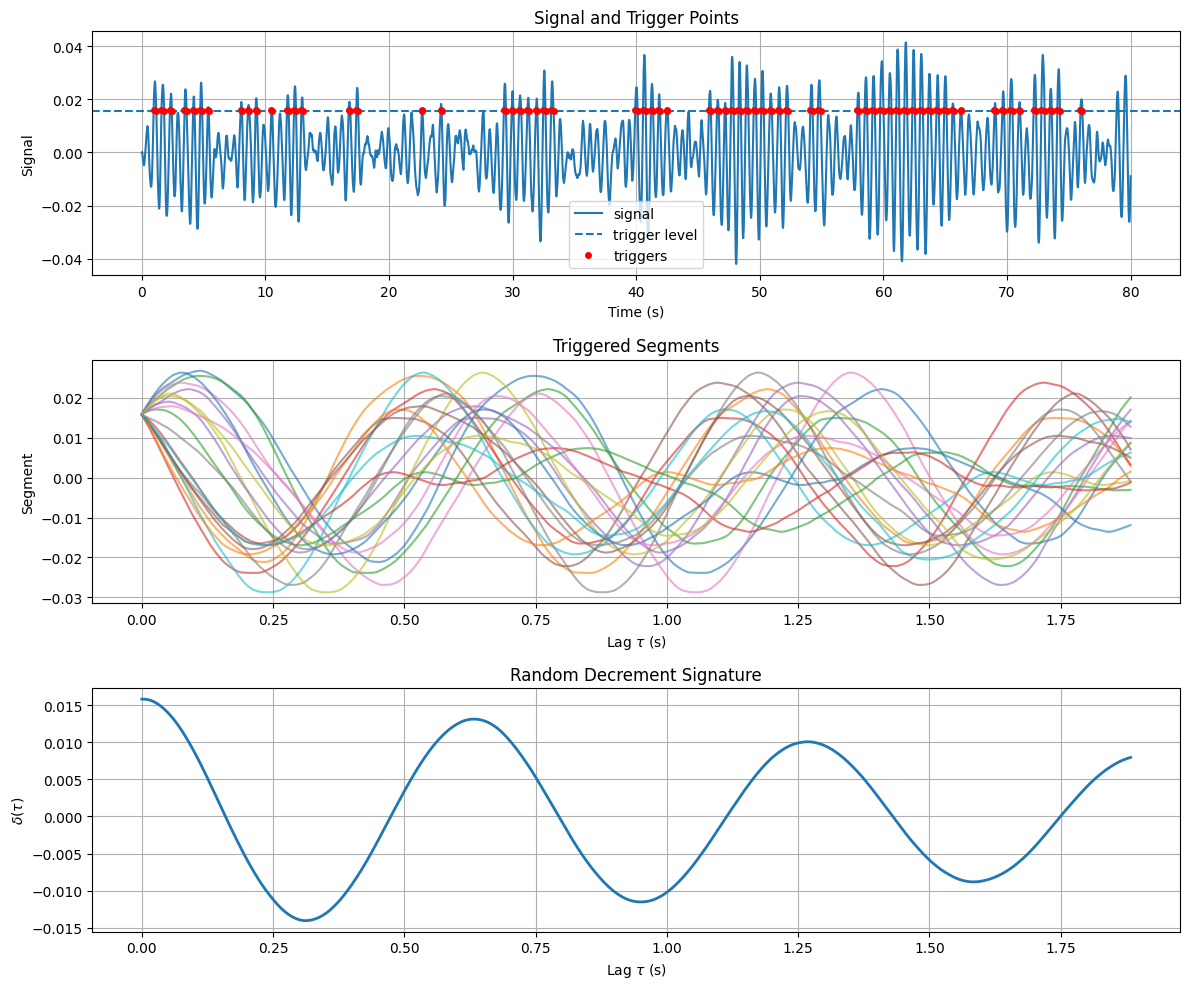

In [20]:
# Choose the signal you want
signal = x          # change to v or a

tau, rd, segments, trig_idx, trig_level, seg_len = random_decrement(
    signal=signal,
    dt=dt,
    m=m,
    k=k,
    trigger_ratio=1.1,
    trigger_mode="any",   # 'up', 'down', or 'any'
    n_cycles=3,           # shorter segment than before
    min_gap=0           # default to segment_length
)

print(f"Trigger level      = {trig_level:.6f}")
print(f"Segment length     = {seg_len} samples")
print(f"Number of segments = {len(segments)}")

time_full = np.arange(len(signal)) * dt

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Full signal with triggers
axes[0].plot(time_full, signal, label='signal')
axes[0].axhline(trig_level, linestyle='--', label='trigger level')
axes[0].plot(trig_idx * dt, signal[trig_idx], 'ro', markersize=4, label='triggers')
axes[0].set_title('Signal and Trigger Points')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Signal')
axes[0].grid(True)
axes[0].legend()

# Raw segments
n_show = min(20, len(segments))
for i in range(n_show):
    axes[1].plot(tau, segments[i], alpha=0.6)
axes[1].set_title('Triggered Segments')
axes[1].set_xlabel(r'Lag $\tau$ (s)')
axes[1].set_ylabel('Segment')
axes[1].grid(True)

# RD signature
axes[2].plot(tau, rd, linewidth=2)
axes[2].set_title('Random Decrement Signature')
axes[2].set_xlabel(r'Lag $\tau$ (s)')
axes[2].set_ylabel(r'$\delta(\tau)$')
axes[2].grid(True)

plt.tight_layout()
plt.show()